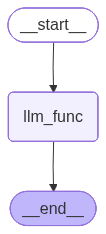

In [1]:
from langchain_openai import ChatOpenAI
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from IPython.display import Image,display

llm = ChatOpenAI(model="gpt-4o-mini")

class State(TypedDict):
    messages : Annotated[list,add_messages]


def llm_func(state:State):
    return {"messages":llm.invoke(state['messages'])}

builder = StateGraph(State)

builder.add_node("llm_func",llm_func)

builder.add_edge(START,"llm_func")

builder.add_edge("llm_func",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
graph.invoke({"messages":"Explain me about AI"})

{'messages': [HumanMessage(content='Explain me about AI', additional_kwargs={}, response_metadata={}, id='04dd3113-b36b-4154-8168-d1f1e50c611e'),
  AIMessage(content="Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. It encompasses a wide range of technologies and applications designed to perform tasks that would otherwise require human intelligence. These tasks can include reasoning, learning, problem-solving, perception, language understanding, and even social and emotional intelligence.\n\n### Key Concepts in AI:\n\n1. **Machine Learning (ML)**: A subset of AI that involves the use of algorithms and statistical models that enable computers to improve their performance on a task through experience. ML is often divided into:\n   - **Supervised Learning**: The model is trained on labeled data, learning to make predictions based on input-output pairs.\n   - **Unsupervised Learning**: The model finds patterns